Kalau bingung di readme ada penjelasannya kok

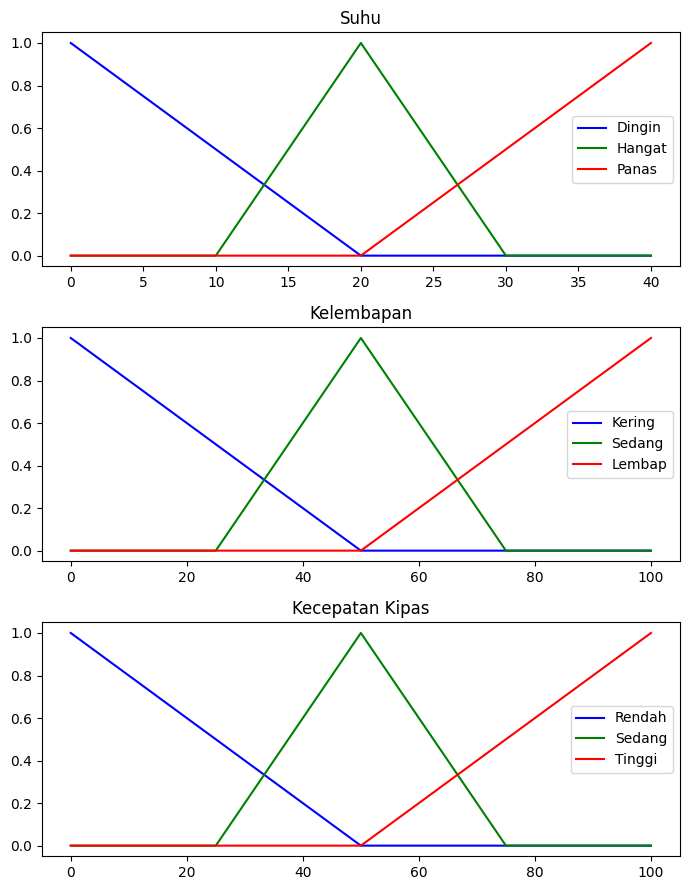

Hasil defuzzifikasi (kecepatan kipas): 80.56


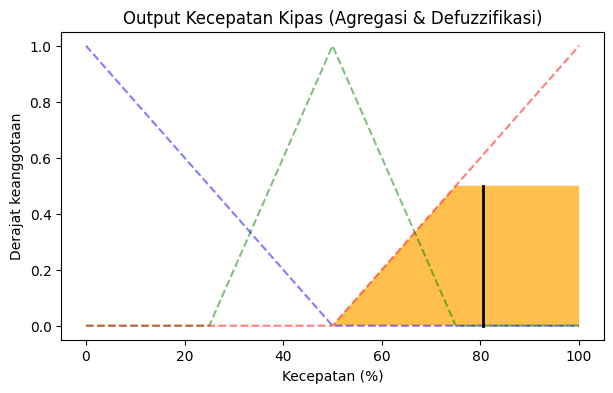

In [1]:
# ---[ 1. Import library ]---
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# ---[ 2. Definisikan domain (semesta pembicaraan) ]---
x_temp = np.arange(0, 41, 1)      # suhu: 0-40 °C
x_hum  = np.arange(0, 101, 1)     # kelembapan: 0-100 %
x_speed = np.arange(0, 101, 1)    # kecepatan kipas: 0-100 %

# ---[ 3. Definisikan himpunan fuzzy (fungsi keanggotaan) ]---

# Suhu
temp_cold = fuzz.trimf(x_temp, [0, 0, 20])
temp_warm = fuzz.trimf(x_temp, [10, 20, 30])
temp_hot  = fuzz.trimf(x_temp, [20, 40, 40])

# Kelembapan
hum_dry  = fuzz.trimf(x_hum, [0, 0, 50])
hum_moderate = fuzz.trimf(x_hum, [25, 50, 75])
hum_wet  = fuzz.trimf(x_hum, [50, 100, 100])

# Kecepatan kipas
speed_low  = fuzz.trimf(x_speed, [0, 0, 50])
speed_med  = fuzz.trimf(x_speed, [25, 50, 75])
speed_high = fuzz.trimf(x_speed, [50, 100, 100])

# ---[ 4. Visualisasi membership function ]---
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(7, 9))

ax1.plot(x_temp, temp_cold, 'b', label='Dingin')
ax1.plot(x_temp, temp_warm, 'g', label='Hangat')
ax1.plot(x_temp, temp_hot, 'r', label='Panas')
ax1.set_title('Suhu')
ax1.legend()

ax2.plot(x_hum, hum_dry, 'b', label='Kering')
ax2.plot(x_hum, hum_moderate, 'g', label='Sedang')
ax2.plot(x_hum, hum_wet, 'r', label='Lembap')
ax2.set_title('Kelembapan')
ax2.legend()

ax3.plot(x_speed, speed_low, 'b', label='Rendah')
ax3.plot(x_speed, speed_med, 'g', label='Sedang')
ax3.plot(x_speed, speed_high, 'r', label='Tinggi')
ax3.set_title('Kecepatan Kipas')
ax3.legend()

plt.tight_layout()
plt.show()

# ---[ 5. Input crisp (nilai aktual) ]---
temp_input = 30   # suhu dalam °C
hum_input = 70    # kelembapan dalam %

# ---[ 6. Fuzzifikasi input ]---
temp_level_cold = fuzz.interp_membership(x_temp, temp_cold, temp_input)
temp_level_warm = fuzz.interp_membership(x_temp, temp_warm, temp_input)
temp_level_hot  = fuzz.interp_membership(x_temp, temp_hot, temp_input)

hum_level_dry = fuzz.interp_membership(x_hum, hum_dry, hum_input)
hum_level_moderate = fuzz.interp_membership(x_hum, hum_moderate, hum_input)
hum_level_wet = fuzz.interp_membership(x_hum, hum_wet, hum_input)

# ---[ 7. Aturan fuzzy (IF-THEN rules) ]---
# R1: IF suhu Dingin OR kelembapan Kering THEN kecepatan Rendah
rule1 = np.fmax(temp_level_cold, hum_level_dry)

# R2: IF suhu Hangat THEN kecepatan Sedang
rule2 = temp_level_warm

# R3: IF suhu Panas OR kelembapan Lembap THEN kecepatan Tinggi
rule3 = np.fmax(temp_level_hot, hum_level_wet)

# ---[ 8. Implikasi aturan ke output fuzzy ]---
activation_low = np.fmin(rule1, speed_low)
activation_med = np.fmin(rule2, speed_med)
activation_high = np.fmin(rule3, speed_high)

# ---[ 9. Agregasi semua aturan ]---
aggregated = np.fmax(activation_low,
              np.fmax(activation_med, activation_high))

# ---[ 10. Defuzzifikasi (Center of Gravity) ]---
fan_speed = fuzz.defuzz(x_speed, aggregated, 'centroid')
fan_activation = fuzz.interp_membership(x_speed, aggregated, fan_speed)

print(f"Hasil defuzzifikasi (kecepatan kipas): {fan_speed:.2f}")

# ---[ 11. Visualisasi hasil ]---
plt.figure(figsize=(7,4))
plt.plot(x_speed, speed_low, 'b', linestyle='--', alpha=0.5)
plt.plot(x_speed, speed_med, 'g', linestyle='--', alpha=0.5)
plt.plot(x_speed, speed_high, 'r', linestyle='--', alpha=0.5)
plt.fill_between(x_speed, np.zeros_like(x_speed), aggregated, facecolor='orange', alpha=0.7)
plt.plot([fan_speed, fan_speed], [0, fan_activation], 'k', linewidth=2)
plt.title('Output Kecepatan Kipas (Agregasi & Defuzzifikasi)')
plt.xlabel('Kecepatan (%)')
plt.ylabel('Derajat keanggotaan')
plt.show()
